# Evaluación del modelo y análisis del umbral de clasificación(Dataset balanceado)

Importamos las librerias necesarias.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    average_precision_score
)

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

## Carga del dataset limpio

En esta sección se carga la versión balanceada del conjunto de datos preparada en sesiones anteriores.

Además, se verifica que la variable objetivo tenga el nombre `default_next_month` y, si es necesario, se reconstruye la variable `AGE_GROUP` para usarla como predictor categórico en el modelo.

In [2]:
ruta_csv = "../data/default_credit_balanced.csv"

df = pd.read_csv(ruta_csv)

if "default payment next month" in df.columns:
    df = df.rename(columns={"default payment next month": "default_next_month"})

if "PAY_0" in df.columns:
    df = df.rename(columns={"PAY_0": "PAY_1"})

if "AGE_GROUP" not in df.columns:
    bins = [20, 30, 40, 50, 60, 80]
    labels = ["20-29", "30-39", "40-49", "50-59", "60+"]
    df["AGE_GROUP"] = pd.cut(df["AGE"], bins=bins, labels=labels, right=False)

print("Dimensiones del dataset:", df.shape)
print("\nPrimeras columnas:")
print(df.columns.tolist()[:10])
df.head()

Dimensiones del dataset: (30000, 30)

Primeras columnas:
['ORIGINAL_ID', 'ID', 'LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_1', 'PAY_2', 'PAY_3']


,ORIGINAL_ID,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_1,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default_next_month,SEX_LABEL,EDUCATION_LABEL,MARRIAGE_LABEL,AGE_GROUP
0,22083,1,90000,2,1,2,28,0,0,0,2,2,2,38355,39413,41181,41701,44000,45651,1700,2404,1500,3000,2500,600,0,Femenino,Posgrado,Soltero,20-29
1,20843,2,180000,1,1,1,40,-2,-2,-2,-2,-2,-2,0,0,0,0,0,0,0,0,0,0,0,0,1,Masculino,Posgrado,Casado,40-49
2,6774,3,470000,2,2,2,32,0,0,0,0,0,0,491428,488642,485382,360959,338592,123737,300000,15937,11891,120000,6380,250000,1,Femenino,Universidad,Soltero,30-39
3,17389,4,130000,2,2,2,44,2,0,0,2,2,2,72181,73086,78411,79725,81311,83048,2700,6500,3200,3500,3200,3300,1,Femenino,Universidad,Soltero,40-49
4,17378,5,210000,2,1,1,38,1,-2,-1,-1,-1,-1,0,0,517,-1,932,1066,0,517,0,933,1066,462,0,Femenino,Posgrado,Casado,30-39


El conjunto de datos se cargó correctamente y contiene **30,000 observaciones** y **30 variables**. Esto confirma que estamos trabajando con la base completa y que ya incluye algunas columnas auxiliares útiles, como:

- `SEX_LABEL`
- `EDUCATION_LABEL`
- `MARRIAGE_LABEL`
- `AGE_GROUP`

Además, se observa que la variable objetivo ya aparece con el nombre **`default_next_month`**, lo cual facilita su uso en el modelado.

Las primeras filas muestran que el dataset contiene:

- variables demográficas (`SEX`, `EDUCATION`, `MARRIAGE`, `AGE`),
- variables de historial de pago (`PAY_1`, `PAY_2`, ..., `PAY_6`),
- variables de facturación (`BILL_AMT1`, ..., `BILL_AMT6`),
- variables de pagos previos (`PAY_AMT1`, ..., `PAY_AMT6`),
- y la variable objetivo de incumplimiento.

Con esto, el conjunto de datos está listo para separar predictores y variable objetivo.

## Separación de predictores y variable objetivo

En esta sección se define:

- `X`: conjunto de variables predictoras,
- `y`: variable objetivo `default_next_month`.

Además, se excluyen columnas que no deben entrar directamente al modelo, como:

- el identificador `ID` y `ORIGINAL_ID`
- y las etiquetas de texto auxiliares (`SEX_LABEL`, `EDUCATION_LABEL`, `MARRIAGE_LABEL`).

Estas columnas son útiles para interpretación, pero no para el ajuste del modelo.

In [3]:
cols_to_drop = ["default_next_month"]
optional_drop = ["ID", "ORIGINAL_ID", "SEX_LABEL", "EDUCATION_LABEL", "MARRIAGE_LABEL"]

for col in optional_drop:
    if col in df.columns:
        cols_to_drop.append(col)

X = df.drop(columns=cols_to_drop)
y = df["default_next_month"]

print("Dimensiones de X:", X.shape)
print("Dimensiones de y:", y.shape)
print("\nColumnas de X:")
print(X.columns.tolist())

Dimensiones de X: (30000, 24)
Dimensiones de y: (30000,)

Columnas de X:
['LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_1', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'AGE_GROUP']


## Distribución de la variable objetivo

Antes de entrenar o evaluar el modelo, conviene revisar cómo se distribuyen las clases de la variable objetivo.

Esto permite identificar si el problema está balanceado o desbalanceado, lo cual es importante porque puede afectar la interpretación de métricas como `accuracy`, `precision` y `recall`.

In [4]:
target_dist = y.value_counts().sort_index().to_frame("count")
target_dist["proportion"] = y.value_counts(normalize=True).sort_index()
target_dist

,count,proportion
default_next_month,,
0,17400,0.5800
1,12600,0.4200



La variable objetivo presenta dos clases:

- **0 = no incumplimiento:** 17,400 casos (**58%**)
- **1 = incumplimiento:** 12,600 casos (**42%**)

En este caso no se observa **desbalanceado** muy marcado, a pesar de que la mayoría de las observaciones corresponde a clientes que **no incumplieron**.

En conjuntos balanceados y desbalanceados, una métrica como el **accuracy** nos puede dar una impresión demasiado optimista del modelo. Por ello, en importante revisar las siguientes metricas:

- **precision**,
- **recall**,
- **F1-score**,
- y **ROC-AUC**.

En particular, como el interés del problema está en detectar clientes con riesgo de incumplimiento, será fundamental observar qué tan bien identifica el modelo la clase `1`.

## Visualización de la variable objetivo

Además de la tabla de frecuencias, es útil visualizar la distribución de la variable objetivo mediante una gráfica de barras.

Esto permite apreciar de forma más inmediata el desbalance entre las clases.

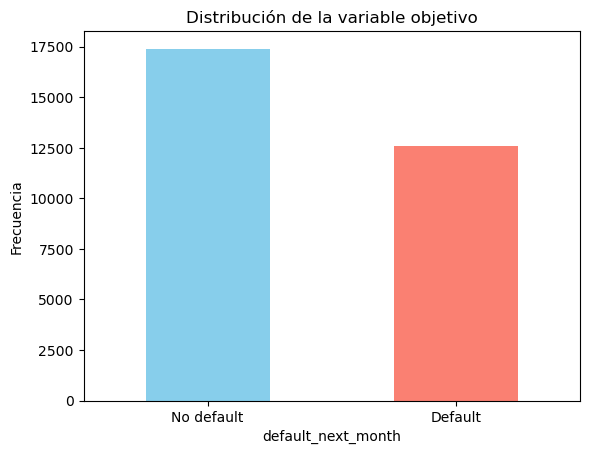

In [5]:
y.value_counts().sort_index().plot(kind="bar", color=["skyblue", "salmon"])
plt.xticks([0, 1], ["No default", "Default"], rotation=0)
plt.ylabel("Frecuencia")
plt.title("Distribución de la variable objetivo")
plt.show()

## Identificación de variables numéricas y categóricas

Antes de construir el pipeline de preprocesamiento, es necesario distinguir qué variables serán tratadas como:

- **categóricas**, que se codificarán con `one-hot encoding`,
- **numéricas**, que se imputarán y escalarán.

En esta sesión se considerarán como categóricas:

- `SEX`
- `EDUCATION`
- `MARRIAGE`
- `AGE_GROUP`

El resto de las variables se tratarán como numéricas.

## Tarea 4

Evaluar la regresión logística con los umbrales `0.3`, `0.5` y `0.6`, comparar `precision`, `recall` y `F1-score`, y escribir una conclusión breve indicando cuál umbral recomendaría y por qué.